# Load Feature Engineered Dataset

This notebook uses the feature-engineered dataset prepared by the team.

Feature engineering was performed during a previous stage of the project and includes:

- Temporal features
- Weather features
- Airport features
- Route features

The objective of this notebook is to evaluate predictive models using the prepared dataset.

In [29]:
import pandas as pd
import numpy as np
import pyarrow


# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Encoding
from sklearn.preprocessing import (
    LabelEncoder,
    OneHotEncoder,
    StandardScaler
)

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_extraction import FeatureHasher
from sklearn.preprocessing import FunctionTransformer

# Model
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay
)

# Save objects
import joblib

# Load Dataset

In [3]:
df = pd.read_parquet("../.data/flights_features.parquet")

print(f"Dataset shape: {df.shape}")

display(df.head())

Dataset shape: (2964978, 56)


,airline_icao,origin_icao,destination_icao,dep_scheduled,origin_elevation_ft,origin_region,destination_elevation_ft,destination_region,origin_wx_temperature_2m,origin_wx_precipitation,...,origin_wx_is_storm,destination_wx_is_fog,destination_wx_is_rain,destination_wx_is_storm,route_hist_delay_mean,route_hist_delay_std,route_hist_delay_rate,airline_hour_delay_rate,airline_hour_delay_mean,is_delayed
0,TAM,SBRJ,SBGR,2022-01-06 14:20:00,11.0,BR-RJ,2461.0,BR-SP,29.081499,0.0,...,0,0,1,0,4.49935,21.865698,0.157437,0.1633,5.6279,0
1,TAM,SBRJ,SBGR,2022-01-07 14:20:00,11.0,BR-RJ,2461.0,BR-SP,24.531500,0.5,...,0,0,1,0,4.49935,21.865698,0.157437,0.1633,5.6279,1
2,TAM,SBRJ,SBGR,2022-01-08 14:20:00,11.0,BR-RJ,2461.0,BR-SP,23.881498,0.6,...,0,0,1,0,4.49935,21.865698,0.157437,0.1633,5.6279,0
3,TAM,SBRJ,SBGR,2022-01-09 14:20:00,11.0,BR-RJ,2461.0,BR-SP,24.281500,0.4,...,0,0,1,0,4.49935,21.865698,0.157437,0.1633,5.6279,0
4,TAM,SBRJ,SBGR,2022-01-11 14:20:00,11.0,BR-RJ,2461.0,BR-SP,25.631498,0.0,...,0,0,0,0,4.49935,21.865698,0.157437,0.1633,5.6279,0


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2964978 entries, 0 to 2964977
Data columns (total 56 columns):
 #   Column                           Dtype         
---  ------                           -----         
 0   airline_icao                     str           
 1   origin_icao                      str           
 2   destination_icao                 str           
 3   dep_scheduled                    datetime64[ns]
 4   origin_elevation_ft              float64       
 5   origin_region                    str           
 6   destination_elevation_ft         float64       
 7   destination_region               str           
 8   origin_wx_temperature_2m         float32       
 9   origin_wx_precipitation          float32       
 10  origin_wx_windspeed_10m          float32       
 11  origin_wx_windgusts_10m          float32       
 12  origin_wx_cloudcover             float32       
 13  origin_wx_surface_pressure       float32       
 14  destination_wx_temperature_2m    float32     

In [5]:
df.columns.tolist()

['airline_icao',
 'origin_icao',
 'destination_icao',
 'dep_scheduled',
 'origin_elevation_ft',
 'origin_region',
 'destination_elevation_ft',
 'destination_region',
 'origin_wx_temperature_2m',
 'origin_wx_precipitation',
 'origin_wx_windspeed_10m',
 'origin_wx_windgusts_10m',
 'origin_wx_cloudcover',
 'origin_wx_surface_pressure',
 'destination_wx_temperature_2m',
 'destination_wx_precipitation',
 'destination_wx_windspeed_10m',
 'destination_wx_windgusts_10m',
 'destination_wx_cloudcover',
 'destination_wx_surface_pressure',
 'dep_day_of_year',
 'dep_is_weekend',
 'dep_hour_sin',
 'dep_hour_cos',
 'dep_dow_sin',
 'dep_dow_cos',
 'dep_month_sin',
 'dep_month_cos',
 'dep_time_block',
 'dep_is_peak_hour',
 'dep_is_holiday',
 'route',
 'region_pair',
 'distance_km',
 'flight_range',
 'elevation_diff_ft',
 'origin_airport_size',
 'destination_airport_size',
 'is_trunk_route',
 'origin_hourly_flights',
 'destination_hourly_arrivals',
 'total_hourly_congestion',
 'origin_wx_condition',
 'd

In [6]:
# Define Features and Target

TARGET = "is_delayed"
METADATA = ["dep_scheduled"]

CAT_COLS = [
    "airline_icao",
    "origin_icao",
    "destination_icao",
    "origin_region",
    "destination_region",
    "route",
    "region_pair",
    "flight_range",
    "dep_time_block",
    "origin_wx_condition",
    "destination_wx_condition",
]

X = df.drop(columns=[TARGET] + METADATA)
y = df[TARGET]

In [7]:
df["dep_scheduled"].head()

0   2022-01-06 14:20:00
1   2022-01-07 14:20:00
2   2022-01-08 14:20:00
3   2022-01-09 14:20:00
4   2022-01-11 14:20:00
Name: dep_scheduled, dtype: datetime64[ns]

In [8]:
df["is_delayed"].value_counts(normalize=True)

is_delayed
0    0.850687
1    0.149313
Name: proportion, dtype: float64

In [9]:

print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")

print("\nMissing values - Top 10:")
display(
    df.isna()
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTarget distribution:")
display(df["is_delayed"].value_counts().sort_index())

print("\nTarget distribution (%):")
display(
    df["is_delayed"]
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

DATASET OVERVIEW
Rows: 2,964,978
Columns: 56

Missing values - Top 10:


route_hist_delay_std        166
origin_airport_size          42
destination_airport_size     42
airline_icao                  0
total_hourly_congestion       0
dep_is_holiday                0
route                         0
region_pair                   0
distance_km                   0
flight_range                  0
dtype: int64


Target distribution:


is_delayed
0    2522268
1     442710
Name: count, dtype: int64


Target distribution (%):


is_delayed
0    85.07
1    14.93
Name: proportion, dtype: float64

In [10]:
df["route_hist_delay_std"].isna().mean() * 100

np.float64(0.005598692469218996)

In [11]:
# Identify categorical columns

X.dtypes.value_counts()

float64     17
int64       13
float32     12
str         10
int32        1
category     1
Name: count, dtype: int64

In [12]:
# Identify categorical features

categorical_cols = X.select_dtypes(
    include=["object", "string", "category"]
).columns.tolist()

print(f"Categorical columns ({len(categorical_cols)}):\n")

for col in categorical_cols:
    print(f"• {col}")

Categorical columns (11):

• airline_icao
• origin_icao
• destination_icao
• origin_region
• destination_region
• dep_time_block
• route
• region_pair
• flight_range
• origin_wx_condition
• destination_wx_condition


In [13]:
# Number of unique values per categorical feature

categorical_summary = (
    X[categorical_cols]
    .nunique()
    .sort_values(ascending=False)
    .to_frame("Unique Values")
)

categorical_summary

,Unique Values
route,1720
region_pair,481
destination_icao,205
origin_icao,204
destination_region,42
origin_region,41
airline_icao,18
dep_time_block,4
origin_wx_condition,4
destination_wx_condition,4


## Temporal Train / Validation / Test Split

To avoid temporal leakage, the dataset is split chronologically:

- Train: 2022–2024
- Validation: January–June 2025
- Test: July–December 2025

In [14]:

VAL_CUTOFF = "2025-07-01"

dates = df["dep_scheduled"]

train_mask = dates.dt.year.isin([2022, 2023, 2024])
val_mask = (~train_mask) & (dates < VAL_CUTOFF)
test_mask = (~train_mask) & (dates >= VAL_CUTOFF)

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

print("=" * 40)
print("TEMPORAL SPLIT")
print("=" * 40)

print(f"Train:      {len(X_train):,} rows")
print(f"Validation: {len(X_val):,} rows")
print(f"Test:       {len(X_test):,} rows")

TEMPORAL SPLIT
Train:      2,193,914 rows
Validation: 379,819 rows
Test:       391,245 rows


In [15]:
# Target Distribution by Split

split_distribution = pd.DataFrame({
    "Train (%)": y_train.value_counts(normalize=True).sort_index().mul(100).round(2),
    "Validation (%)": y_val.value_counts(normalize=True).sort_index().mul(100).round(2),
    "Test (%)": y_test.value_counts(normalize=True).sort_index().mul(100).round(2),
})

split_distribution

,Train (%),Validation (%),Test (%)
is_delayed,,,
0,85.05,86.39,83.92
1,14.95,13.61,16.08


In [16]:
# Preprocessing Pipeline

numeric_cols = X_train.select_dtypes(
    include=["int64", "int32", "float64", "float32"]
).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

# Lighter categorical transformer

def to_dict_records(X):
    return pd.DataFrame(X).astype(str).to_dict(orient="records")

categorical_transformer = Pipeline(
    steps=[
        ("to_dict", FunctionTransformer(to_dict_records, validate=False)),
        ("hasher", FeatureHasher(n_features=512, input_type="dict"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_cols),
        ("cat", categorical_transformer, categorical_cols)
    ]
)

print("=" * 60)
print("PREPROCESSING PIPELINE")
print("=" * 60)
print(f"Numerical features: {len(numeric_cols)}")
print(f"Categorical features: {len(categorical_cols)}")
print("Categorical encoding: FeatureHasher")
print("Hashing features: 512")

PREPROCESSING PIPELINE
Numerical features: 43
Categorical features: 11
Categorical encoding: FeatureHasher
Hashing features: 512


In [17]:
# Baseline Logistic Regression Pipeline

baseline_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=1000,
            class_weight="balanced",
            random_state=42
        ))
    ]
)

baseline_model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the

In [23]:
from sklearn.model_selection import train_test_split

sample_size = 800_000

X_train_sample, _, y_train_sample, _ = train_test_split(
    X_train,
    y_train,
    train_size=sample_size,
    stratify=y_train,
    random_state=42,
)

print(X_train_sample.shape)
print(y_train_sample.value_counts(normalize=True))

(800000, 54)
is_delayed
0    0.850454
1    0.149546
Name: proportion, dtype: float64


In [24]:
baseline_model.fit(X_train_sample, y_train_sample)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](54,)","['airline_icao','origin_icao','destination_icao',..., 'route_hist_delay_rate','airline_hour_delay_rate', 'airline_hour_delay_mean']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,54
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of

In [25]:
# Validation Predictions
y_val_pred = baseline_model.predict(X_val)
y_val_proba = baseline_model.predict_proba(X_val)[:, 1]

print("=" * 40)
print("VALIDATION PREDICTIONS")
print("=" * 40)
print("Predictions generated successfully.")

VALIDATION PREDICTIONS
Predictions generated successfully.


In [26]:
# Validation Metrics

print("=" * 40)
print("VALIDATION METRICS - BASELINE LOGISTIC REGRESSION")
print("=" * 40)

print(f"Accuracy:  {accuracy_score(y_val, y_val_pred):.4f}")
print(f"Precision: {precision_score(y_val, y_val_pred):.4f}")
print(f"Recall:    {recall_score(y_val, y_val_pred):.4f}")
print(f"F1-score:  {f1_score(y_val, y_val_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_val, y_val_proba):.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_val_pred, digits=3))

VALIDATION METRICS - BASELINE LOGISTIC REGRESSION
Accuracy:  0.6532
Precision: 0.1961
Recall:    0.4991
F1-score:  0.2815
ROC-AUC:   0.6339

Classification Report:
              precision    recall  f1-score   support

           0      0.896     0.678     0.771    328118
           1      0.196     0.499     0.282     51701

    accuracy                          0.653    379819
   macro avg      0.546     0.588     0.526    379819
weighted avg      0.800     0.653     0.705    379819



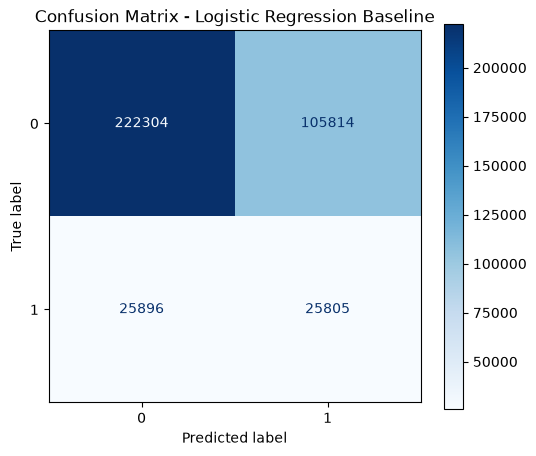

In [30]:
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_val,
    y_val_pred,
    cmap="Blues",
    ax=ax
)

plt.title("Confusion Matrix - Logistic Regression Baseline")
plt.show()

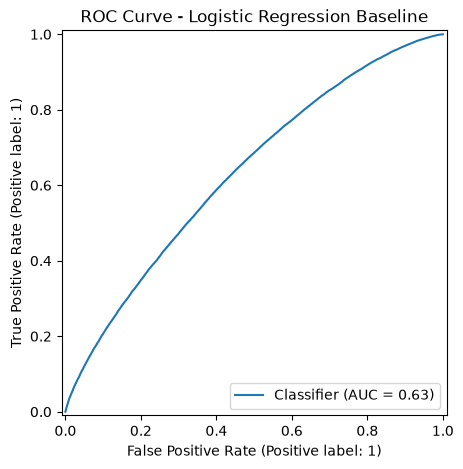

In [31]:
fig, ax = plt.subplots(figsize=(6, 5))

RocCurveDisplay.from_predictions(
    y_val,
    y_val_proba,
    ax=ax
)

plt.title("ROC Curve - Logistic Regression Baseline")
plt.show()

# Conclusion

The primary evaluation metric adopted in this project is ROC-AUC, as it provides a threshold-independent measure of the model's ability to distinguish delayed from non-delayed flights and is more appropriate for this moderately imbalanced classification problem.

The Logistic Regression baseline achieved a ROC-AUC of 0.634 on the validation set, providing an initial benchmark for model evaluation.

Although the baseline reached a Recall of approximately 0.50, its Precision (0.20) and F1-score (0.28) indicate that there is considerable room for improvement.